# Road segmentation - D-LinkNet34

Trains on the unified 512x512 corpus (64,979 patches from DeepGlobe, Massachusetts,
RNGDet and SpaceNet 3)

Sized for RTX 5060 8.5 GB + i5-14600KF


In [1]:
"""Train D-LinkNet34 on the unified 512x512 road corpus.

Loss = focal BCE + relaxed soft-F1 (offset-tolerant) + mass calibration.
No clDice: at constant stroke width, volume = W * centreline length, so the
skeleton-based sensitivity term is proportional to plain recall and buys nothing,
while the skeleton-based precision term costs 18 indexed max-pools and an
unstable denominator. clDice survives as an eval metric only, on hard masks.
"""

import math
import os
import random
import time

# Workers already run torch.set_num_threads(1) internally (see
# torch/utils/data/_utils/worker.py). Without this, the *main* process
# defaults to one ATen intra-op thread per physical core (14 here) for
# every small CPU op (batch collate, etc.) -- that fires alongside the
# 3 worker processes each batch and repeatedly boosts most P-cores at
# once, which is what was spiking core temps to 95C. Training is GPU-
# bound; the main process needs only a couple of threads.
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

from dlinknet import DLinkNet34
from road_dataset import RoadDataset, normalize
from huggingface_hub import hf_hub_download

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

ROOT = r"C:\Dev\deeplearning\unified_dataset"
CKPT_DIR = r"C:\Dev\deeplearning\trained_models"

EPOCHS = 30
BATCH = 32              # sweet spot: 141-148 img/s is flat from batch 16-40
                        # (compute-bound, not memory-bound) -- 32 keeps 3GB
                        # headroom under the 8GB card while halving step count
                        # vs. 16. >=48 overflows physical VRAM: Windows falls
                        # back to system RAM instead of raising OOM, and
                        # throughput collapses (79 img/s at 48, 31 at 56...).
WORKERS = 3
SAMPLER_POWER = 0.5
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_STEPS = 250      # halved with BATCH 16->32: same 13.5% of the run
GRAD_CLIP = 1.0
BN_FREEZE = 150         # halved with BATCH: same ~8% of the run. encoder BN
                        # stats adapt at momentum 0.1 regardless of LR
VAL_EVERY = 1850        # == steps/epoch -> one eval per epoch, scales with
                        # EPOCHS automatically (was tuned for EPOCHS=1; a
                        # fixed step count doesn't generalize to 30)
SEED = 42

FOCAL_ALPHA = 0.75
RHO = 2                 # train-time tolerance, ~half the 3-6 px stroke width
EVAL_RHO = 3            # Mnih & Hinton relaxed metric radius for Massachusetts
SMOOTH = 1.0            # in pixel-count units, so it is scale-consistent
W_FOCAL = 1.0
W_REL = 1.0
W_MASS = 0.5            # dL_mass/du|0 = 1/W vs dTI/du|0; see derivation

DEVICE = torch.device("cuda")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)         # see OMP_NUM_THREADS note above
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")


@torch.compile(dynamic=False)
def road_loss(logits, y):
    z = logits.float()
    p = torch.sigmoid(z)

    # Focal BCE. gamma = 2 as a multiply: adaptive down-weighting of easy
    # negatives, unlike pos_weight which scales every positive by a constant.
    ce = F.binary_cross_entropy_with_logits(z, y, reduction="none")
    pt = p * y + (1 - p) * (1 - y)
    w = FOCAL_ALPHA * y + (1 - FOCAL_ALPHA) * (1 - y)
    m = 1 - pt
    focal = (w * m * m * ce).mean()

    # Relaxed soft-F1. Binary dilation == max_pool2d(2*rho+1, stride 1). The GT
    # buffer needs no gradient, so only one indexed pool enters the graph.
    buf = F.max_pool2d(y, 2 * RHO + 1, 1, RHO)
    pdil = F.max_pool2d(p, 2 * RHO + 1, 1, RHO)
    prec = ((p * buf).sum() + SMOOTH) / (p.sum() + SMOOTH)
    rec = ((y * pdil).sum() + SMOOTH) / (y.sum() + SMOOTH)
    rel = 1 - 2 * prec * rec / (prec + rec)   # both in (0, 1]; no epsilon needed

    # Mass calibration, per image: batch-level mass is satisfiable by fattening
    # one patch and starving another.
    mp = p.sum((1, 2, 3))
    my = y.sum((1, 2, 3))
    mass = ((mp - my).abs() / (mp + my + SMOOTH)).mean()

    return W_FOCAL * focal + W_REL * rel + W_MASS * mass, focal, rel, mass


def soft_skeleton(x, iters=3):
    """Union of erosion residues. Exact for binary input; eval metric only."""
    def erode(t):
        return torch.min(-F.max_pool2d(-t, (3, 1), 1, (1, 0)),
                         -F.max_pool2d(-t, (1, 3), 1, (0, 1)))

    def opened(t):
        return F.max_pool2d(erode(t), 3, 1, 1)

    skel = F.relu(x - opened(x))
    for _ in range(iters):
        x = erode(x)
        delta = F.relu(x - opened(x))
        skel = skel + F.relu(delta - skel * delta)
    return skel


@torch.inference_mode()
def evaluate(model, loader, source_names):
    model.eval()
    acc = torch.zeros(len(source_names), 9, dtype=torch.float64, device=DEVICE)
    for images, masks, sids in loader:
        images = normalize(images, DEVICE)
        y = masks.to(DEVICE, non_blocking=True).permute(0, 3, 1, 2).float()
        sids = sids.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            logits = model(images)
        pred = (logits.float() > 0).float()          # sigmoid is monotone; threshold the logit

        pdil = F.max_pool2d(pred, 2 * EVAL_RHO + 1, 1, EVAL_RHO)
        ydil = F.max_pool2d(y, 2 * EVAL_RHO + 1, 1, EVAL_RHO)
        skp, sky = soft_skeleton(pred), soft_skeleton(y)
        acc.index_add_(0, sids, torch.stack([
            (pred * y).sum((1, 2, 3)),
            (pred * (1 - y)).sum((1, 2, 3)),
            ((1 - pred) * y).sum((1, 2, 3)),
            (pred * ydil).sum((1, 2, 3)),
            (y * pdil).sum((1, 2, 3)),
            (skp * y).sum((1, 2, 3)),
            skp.sum((1, 2, 3)),
            (sky * pred).sum((1, 2, 3)),
            sky.sum((1, 2, 3)),
        ], dim=1).double())

    acc = acc.cpu()                                   # one sync per validation, not 7776
    out = {}
    for i, name in enumerate(list(source_names) + ["ALL"]):
        tp, fp, fn, rp, rr, spi, sp, syi, sy = (acc.sum(0) if name == "ALL" else acc[i]).tolist()
        pr, re = rp / max(tp + fp, 1), rr / max(tp + fn, 1)
        tpr, tse = spi / max(sp, 1), syi / max(sy, 1)
        out[name] = {
            "iou": tp / max(tp + fp + fn, 1),
            "f1": 2 * tp / max(2 * tp + fp + fn, 1),
            "rf1": 2 * pr * re / max(pr + re, 1e-9),
            "cldice": 2 * tpr * tse / max(tpr + tse, 1e-9),
            "mass": (tp + fp) / max(tp + fn, 1),      # >1 means the model is over-dilating
        }
    model.train()
    return out


def freeze_encoder_bn(m):
    for mod in m.encoder.modules():
        if isinstance(mod, torch.nn.modules.batchnorm._BatchNorm):
            mod.eval()


if __name__ == "__main__":
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available")
    os.makedirs(CKPT_DIR, exist_ok=True)

    # Was hardcoded to D:\Models\imagenet\model.safetensors -- that drive
    # isn't attached on this machine. Resolve through the HF cache instead
    # (same weights; downloads once, hits the local cache after). Kept
    # inside __main__ -- it's a network/disk call with no reason to run
    # again in every spawned DataLoader worker.
    ENCODER_WEIGHTS = hf_hub_download("smp-hub/resnet34.imagenet", "model.safetensors")

    train_set = RoadDataset(ROOT, "train", augment=True)
    val_set = RoadDataset(ROOT, "val")
    assert len(val_set) % BATCH == 0, "val must divide evenly or dynamo specialises twice"
    print(f"[+] train {len(train_set):,} | val {len(val_set):,}")

    g = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_set, batch_size=BATCH,
                              sampler=train_set.stratified_indices(SAMPLER_POWER, g),
                              num_workers=WORKERS, pin_memory=True,
                              persistent_workers=True, prefetch_factor=2, drop_last=True)
    val_loader = DataLoader(val_set, batch_size=BATCH, shuffle=False, num_workers=2,
                            pin_memory=True, persistent_workers=True)

    model = DLinkNet34(weights=ENCODER_WEIGHTS).to(DEVICE, memory_format=torch.channels_last)

    # Split before compile: torch.compile prefixes every parameter name with
    # "_orig_mod.", which would silently break the startswith("encoder.") test.
    groups = [[], [], [], []]
    for name, param in model.named_parameters():
        if param.requires_grad:
            slot = (0 if name.startswith("encoder.") else 2) + (1 if param.ndim <= 1 else 0)
            groups[slot].append(param)
    optimizer = torch.optim.AdamW([
        {"params": groups[0], "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY},
        {"params": groups[1], "lr": LR_ENCODER, "weight_decay": 0.0},
        {"params": groups[2], "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
        {"params": groups[3], "lr": LR_DECODER, "weight_decay": 0.0},
    ], fused=True)
    enc = groups[0] + groups[1]
    dec = groups[2] + groups[3]

    total_steps = EPOCHS * len(train_loader)

    def schedule(step):
        if step < WARMUP_STEPS:
            return (step + 1) / WARMUP_STEPS
        progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
        return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, schedule)

    raw_model = model
    ema = torch.optim.swa_utils.AveragedModel(
        raw_model, avg_fn=lambda a, c, n: 0.99 * a + 0.01 * c)
    model = torch.compile(model, dynamic=False)

    src_n = {s: val_set.sources.count(s) for s in val_set.source_names}
    z = sum(n ** 0.5 for n in src_n.values())

    print(f"[+] {total_steps:,} steps, batch {BATCH}, bf16 + channels_last")
    step = 0
    best = 0.0
    start = time.time()

    for epoch in range(EPOCHS):
        bar = tqdm(train_loader, desc=f"epoch {epoch + 1}/{EPOCHS}", unit="batch")
        for images, masks, _ in bar:
            images = normalize(images, DEVICE)
            y = masks.to(DEVICE, non_blocking=True).permute(0, 3, 1, 2).float()

            with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                logits = model(images)
            loss, focal, rel, mass = road_loss(logits, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(enc, GRAD_CLIP, error_if_nonfinite=True)
            torch.nn.utils.clip_grad_norm_(dec, GRAD_CLIP, error_if_nonfinite=True)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            step += 1

            if step == BN_FREEZE:
                freeze_encoder_bn(raw_model)
            if step % 4 == 0:
                ema.update_parameters(raw_model)

            if step % 50 == 0:
                bar.set_postfix(f=f"{focal.item():.4f}", r=f"{rel.item():.4f}",
                                m=f"{mass.item():.4f}", lr=f"{scheduler.get_last_lr()[2]:.2e}")

            if step % VAL_EVERY == 0 or step == total_steps:
                s = evaluate(model, val_loader, val_set.source_names)
                if step >= BN_FREEZE:
                    freeze_encoder_bn(raw_model)
                tqdm.write(f"[val] {step:6d}  " + "  ".join(
                    f"{k}: rF1={v['rf1']:.3f} IoU={v['iou']:.3f} clD={v['cldice']:.3f} "
                    f"m={v['mass']:.2f}" for k, v in sorted(s.items())))

                # Select on sqrt-weighted relaxed F1: mirror the sampler, so the
                # selection metric and the training distribution are one object.
                score = sum(s[k]["rf1"] * (n ** 0.5) / z for k, n in src_n.items())
                if score > best:
                    best = score
                    torch.save({"model": raw_model.state_dict(), "ema": ema.module.state_dict(),
                                "step": step, "score": best, "val": s},
                               os.path.join(CKPT_DIR, "dlinknet34_best.pt"))

    elapsed = time.time() - start
    print(f"[+] {total_steps * BATCH / elapsed:.1f} img/s, best balanced rF1 {best:.4f}, "
          f"peak {torch.cuda.max_memory_allocated() / 2**30:.2f} GB / "
          f"reserved {torch.cuda.max_memory_reserved() / 2**30:.2f} GB")

[+] train 59,212 | val 2,592


c:\Dev\deeplearning\.venv\Lib\site-packages\torch\nn\modules\module.py:1363: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  return t.to(


[+] 55,500 steps, batch 32, bf16 + channels_last


epoch 1/30: 100%|██████████| 1850/1850 [09:28<00:00,  3.25batch/s, f=0.0439, lr=9.98e-04, m=0.1874, r=0.2480] 


[val]   1850  ALL: rF1=0.827 IoU=0.267 clD=0.365 m=0.74  deepglobe: rF1=0.799 IoU=0.211 clD=0.341 m=0.68  mass: rF1=0.924 IoU=0.524 clD=0.691 m=0.85  rngdet: rF1=0.853 IoU=0.258 clD=0.401 m=0.82  spacenet: rF1=0.661 IoU=0.098 clD=0.175 m=0.69


...

[val]  51800  ALL: rF1=0.906 IoU=0.353 clD=0.496 m=0.96  deepglobe: rF1=0.898 IoU=0.317 clD=0.499 m=0.95  mass: rF1=0.955 IoU=0.590 clD=0.732 m=0.98  rngdet: rF1=0.921 IoU=0.326 clD=0.508 m=0.97  spacenet: rF1=0.757 IoU=0.140 clD=0.233 m=0.92


epoch 29/30: 100%|██████████| 1850/1850 [06:44<00:00,  4.57batch/s, f=0.0345, lr=2.76e-06, m=0.0737, r=0.1377]


[val]  53650  ALL: rF1=0.906 IoU=0.353 clD=0.495 m=0.95  deepglobe: rF1=0.898 IoU=0.315 clD=0.497 m=0.94  mass: rF1=0.955 IoU=0.590 clD=0.729 m=0.98  rngdet: rF1=0.921 IoU=0.326 clD=0.508 m=0.97  spacenet: rF1=0.757 IoU=0.139 clD=0.232 m=0.92


epoch 30/30: 100%|██████████| 1850/1850 [06:44<00:00,  4.57batch/s, f=0.0353, lr=0.00e+00, m=0.0773, r=0.1393]

[val]  55500  ALL: rF1=0.906 IoU=0.353 clD=0.495 m=0.95  deepglobe: rF1=0.898 IoU=0.316 clD=0.498 m=0.94  mass: rF1=0.955 IoU=0.591 clD=0.727 m=0.99  rngdet: rF1=0.921 IoU=0.326 clD=0.508 m=0.97  spacenet: rF1=0.757 IoU=0.139 clD=0.232 m=0.91
[+] 143.8 img/s, best balanced rF1 0.8870, peak 5.53 GB / reserved 5.58 GB


# POSTPROCESS

[+] saved C:\Dev\deeplearning\postprocess.png


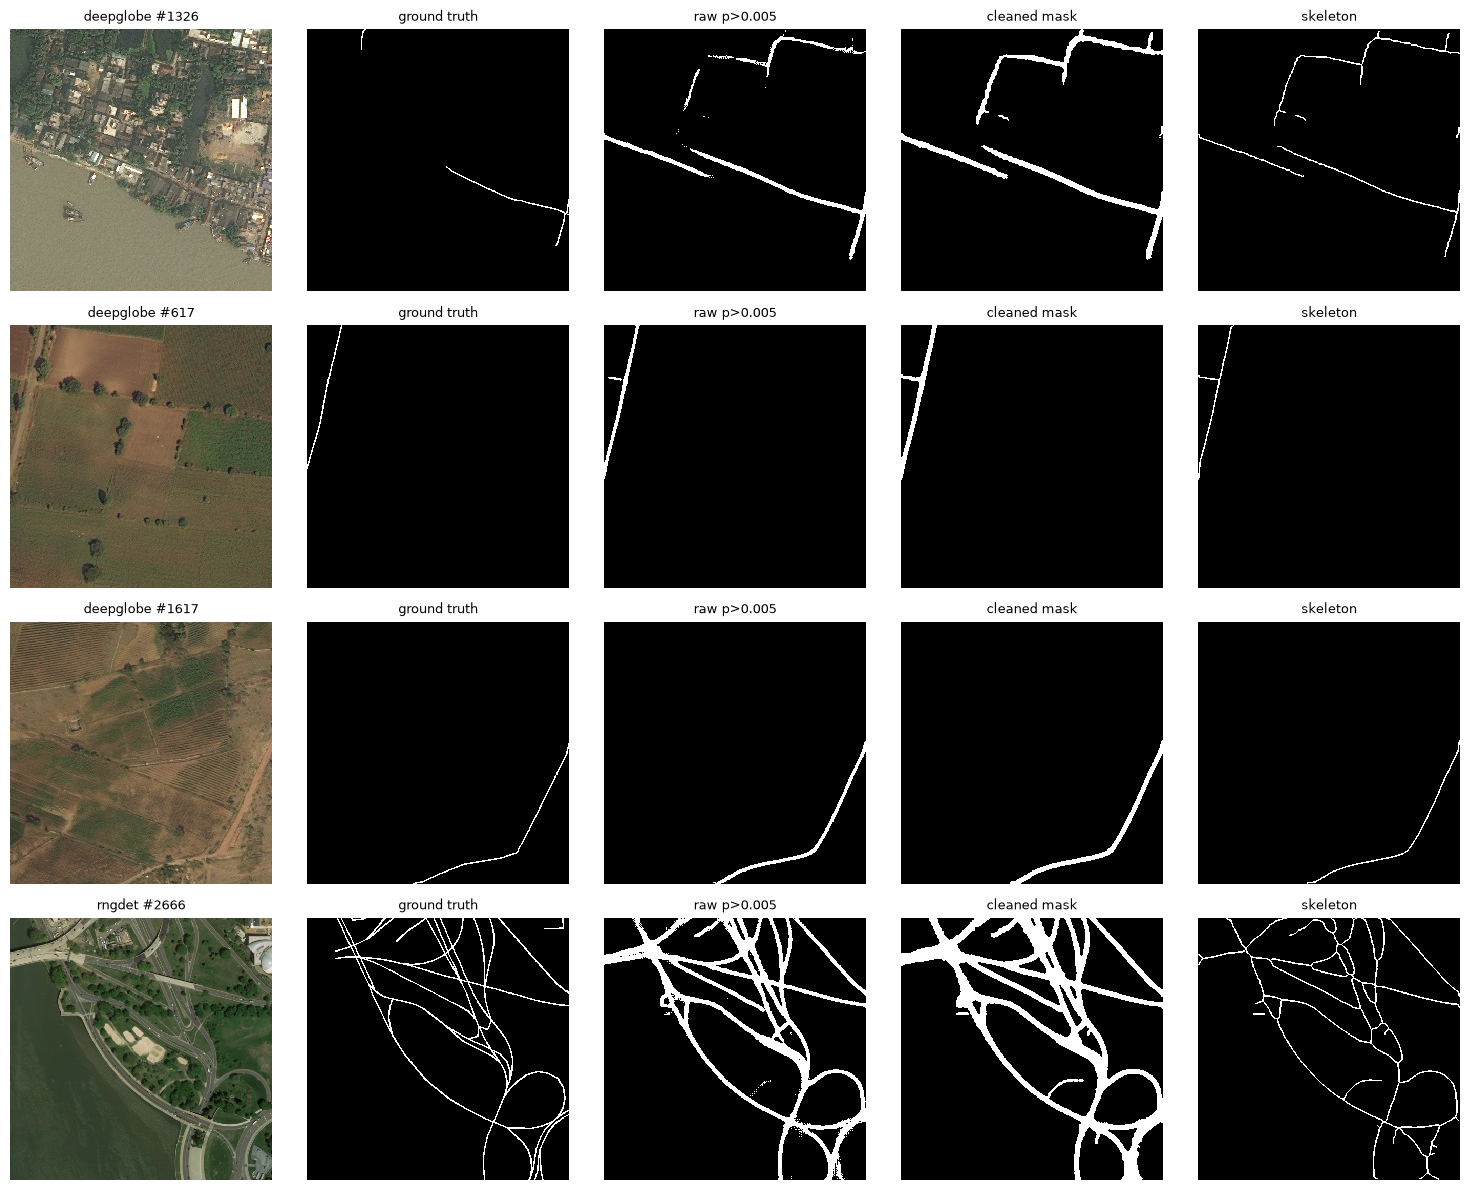

In [3]:
"""Turn D-LinkNet34 probabilities into a clean road mask and a 1-px skeleton.

The model is trusted down to p > 0.005, but at that level the map shows the
decoder's PixelShuffle(2) lattice: low-confidence pixels come out as a period-2
dot pattern, so a raw threshold yields checkerboarded roads and ~130 specks per
patch. The fix is applied to the probabilities, not the binary mask:

  1. gaussian sigma=1   -- suppresses the period-2 lattice before thresholding
                          (dotted fringe -> solid ribbon; specks 129 -> 11)
  2. p > 0.005          -- the operating point
  3. closing, disk(2)   -- bridges 1-4 px gaps along a road and at junctions
  4. fill holes / drop objects < 64 px -- pinholes inside ribbons, isolated blobs
  5. skeletonize        -- centreline graph for path planning

Hysteresis was tested and dropped: after step 1 and 4 it changed nothing.
On 12 test patches, skeleton precision/recall within 3 px of the GT centreline
went from 0.78/0.92 (raw) to 0.82/0.88, with components 129 -> 2.8 and
dangling endpoints 37 -> 12.
"""

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import ndimage as ndi
from skimage import morphology

from dlinknet import DLinkNet34
from road_dataset import RoadDataset, normalize

CKPT = r"C:\Dev\deeplearning\trained_models\dlinknet34_best.pt"
ROOT = r"C:\Dev\deeplearning\unified_dataset"
OUT = r"C:\Dev\deeplearning\postprocess.png"
N_SAMPLES = 4
SEED = 7
THRESHOLD = 0.005
SIGMA = 1.0          # gaussian blur on probabilities, kills the 2x2 lattice
CLOSE_RADIUS = 2     # gap bridging, px
MIN_AREA = 64        # holes and blobs smaller than this are removed, px

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- model -------------------------------------------------------------------
ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
model = DLinkNet34(weights=None).to(device, memory_format=torch.channels_last)
model.load_state_dict(ckpt["model"])
model.eval()

test_set = RoadDataset(ROOT, "test", augment=False)
idxs = random.Random(SEED).sample(range(len(test_set)), N_SAMPLES)

titles = ("image", "ground truth", f"raw p>{THRESHOLD}", "cleaned mask", "skeleton")
fig, axes = plt.subplots(N_SAMPLES, len(titles), figsize=(3 * len(titles), 3 * N_SAMPLES), squeeze=False)

for row, idx in enumerate(idxs):
    image, gt, sid = test_set[idx]

    # --- inference -----------------------------------------------------------
    with torch.inference_mode(), torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=device.type == "cuda"):
        logits = model(normalize(image.unsqueeze(0), device))
    prob = torch.sigmoid(logits.float()).squeeze().cpu().numpy()

    # --- postprocess ---------------------------------------------------------
    raw = prob > THRESHOLD
    mask = ndi.gaussian_filter(prob, SIGMA) > THRESHOLD
    mask = morphology.closing(mask, morphology.disk(CLOSE_RADIUS))
    mask = morphology.remove_small_holes(mask, max_size=MIN_AREA)
    mask = morphology.remove_small_objects(mask, max_size=MIN_AREA)
    skeleton = morphology.skeletonize(mask)

    # --- visualize -----------------------------------------------------------
    panels = (image.numpy(), gt.squeeze().numpy(), raw, mask, ndi.binary_dilation(skeleton))  # dilate only for display
    for col, (ax, im, title) in enumerate(zip(axes[row], panels, titles)):
        ax.imshow(im, cmap=None if col == 0 else "gray", interpolation="nearest")
        ax.set_title(f"{test_set.source_names[sid]} #{idx}" if col == 0 else title, fontsize=9)
        ax.axis("off")

fig.tight_layout()
fig.savefig(OUT, dpi=110)
print(f"[+] saved {OUT}")


# STATS

In [ ]:
"""Score prediction + postprocess on a whole split, per dataset and overall.

Metric: relaxed precision / recall / F1 on skeletons, tolerance 3 px (EVAL_RHO).
  precision = predicted centreline px within 3 px of a GT centreline  -> "is this road real?"
  recall    = GT centreline px within 3 px of a predicted centreline  -> "did we miss a road?"
Precision alone is maximised by predicting almost nothing, so F1 is the headline score.
Skeleton-vs-skeleton makes it independent of stroke width, which differs per
dataset (Massachusetts ribbons are ~2x wider than DeepGlobe/SpaceNet).
Pixel counts are pooled: a dataset row sums its patches, ALL sums every patch.
"""

import numpy as np
import torch
from scipy import ndimage as ndi
from skimage import morphology
from torch.utils.data import DataLoader
from tqdm import tqdm

from dlinknet import DLinkNet34
from road_dataset import RoadDataset, normalize

CKPT = r"C:\Dev\deeplearning\trained_models\dlinknet34_best.pt"
ROOT = r"C:\Dev\deeplearning\unified_dataset"
SPLIT = "test"       # never seen in training or checkpoint selection
BATCH = 16
THRESHOLD = 0.01
SIGMA = 1.0
CLOSE_RADIUS = 2
MIN_AREA = 64
TOL = 3              # px

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
model = DLinkNet34(weights=None).to(device, memory_format=torch.channels_last)
model.load_state_dict(ckpt["model"])
model.eval()

ds = RoadDataset(ROOT, SPLIT, augment=False)
loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
tol_disk = morphology.disk(TOL)
# per dataset: [pred px matched, pred px, gt px matched, gt px, patches]
counts = np.zeros((len(ds.source_names), 5), np.int64)

with torch.inference_mode():
    for images, masks, sids in tqdm(loader, desc=f"evaluating {SPLIT}", unit="batch"):
        with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=device.type == "cuda"):
            logits = model(normalize(images, device))
        probs = torch.sigmoid(logits.float()).squeeze(1).cpu().numpy()

        for prob, gt, sid in zip(probs, masks.squeeze(-1).numpy().astype(bool), sids.tolist()):
            mask = ndi.gaussian_filter(prob, SIGMA) > THRESHOLD
            mask = morphology.closing(mask, morphology.disk(CLOSE_RADIUS))
            mask = morphology.remove_small_holes(mask, max_size=MIN_AREA)
            mask = morphology.remove_small_objects(mask, max_size=MIN_AREA)
            sk_pred = morphology.skeletonize(mask)
            sk_gt = morphology.skeletonize(gt)

            counts[sid] += (
                (sk_pred & ndi.binary_dilation(sk_gt, tol_disk)).sum(), sk_pred.sum(),
                (sk_gt & ndi.binary_dilation(sk_pred, tol_disk)).sum(), sk_gt.sum(), 1)

print(f"\n{'dataset':<10} {'patches':>8} {'precision':>10} {'recall':>8} {'F1':>8}")
for name, (tp_p, n_p, tp_g, n_g, n) in zip(ds.source_names + ["ALL"], [*counts, counts.sum(0)]):
    p, r = tp_p / max(n_p, 1), tp_g / max(n_g, 1)
    print(f"{name:<10} {n:>8} {p:>10.4f} {r:>8.4f} {2 * p * r / max(p + r, 1e-9):>8.4f}")


evaluating test: 100%|██████████| 199/199 [01:20<00:00,  2.48batch/s]


dataset     patches  precision   recall       F1
deepglobe      2137     0.6615   0.8591   0.7474
mass            441     0.6928   0.8518   0.7641
rngdet          432     0.6231   0.7756   0.6910
spacenet        165     0.4563   0.5515   0.4994
ALL            3175     0.6433   0.8135   0.7185


comparing on test: 100%|██████████| 199/199 [02:16<00:00,  1.45batch/s]



dataset    patches |  old U-Net P      R     F1 |  D-LinkNet P      R     F1
deepglobe     2137 |       0.7764 0.7105 0.7420 |       0.6615 0.8591 0.7474
mass           441 |       0.9188 0.8192 0.8661 |       0.6928 0.8518 0.7641
rngdet         432 |       0.7165 0.5792 0.6406 |       0.6231 0.7756 0.6910
spacenet       165 |       0.3097 0.0415 0.0731 |       0.4563 0.5515 0.4994
ALL           3175 |       0.7754 0.6479 0.7059 |       0.6433 0.8135 0.7185
MEAN               |                     0.5805 |                     0.6755
[+] saved C:\Dev\deeplearning\comparison.png


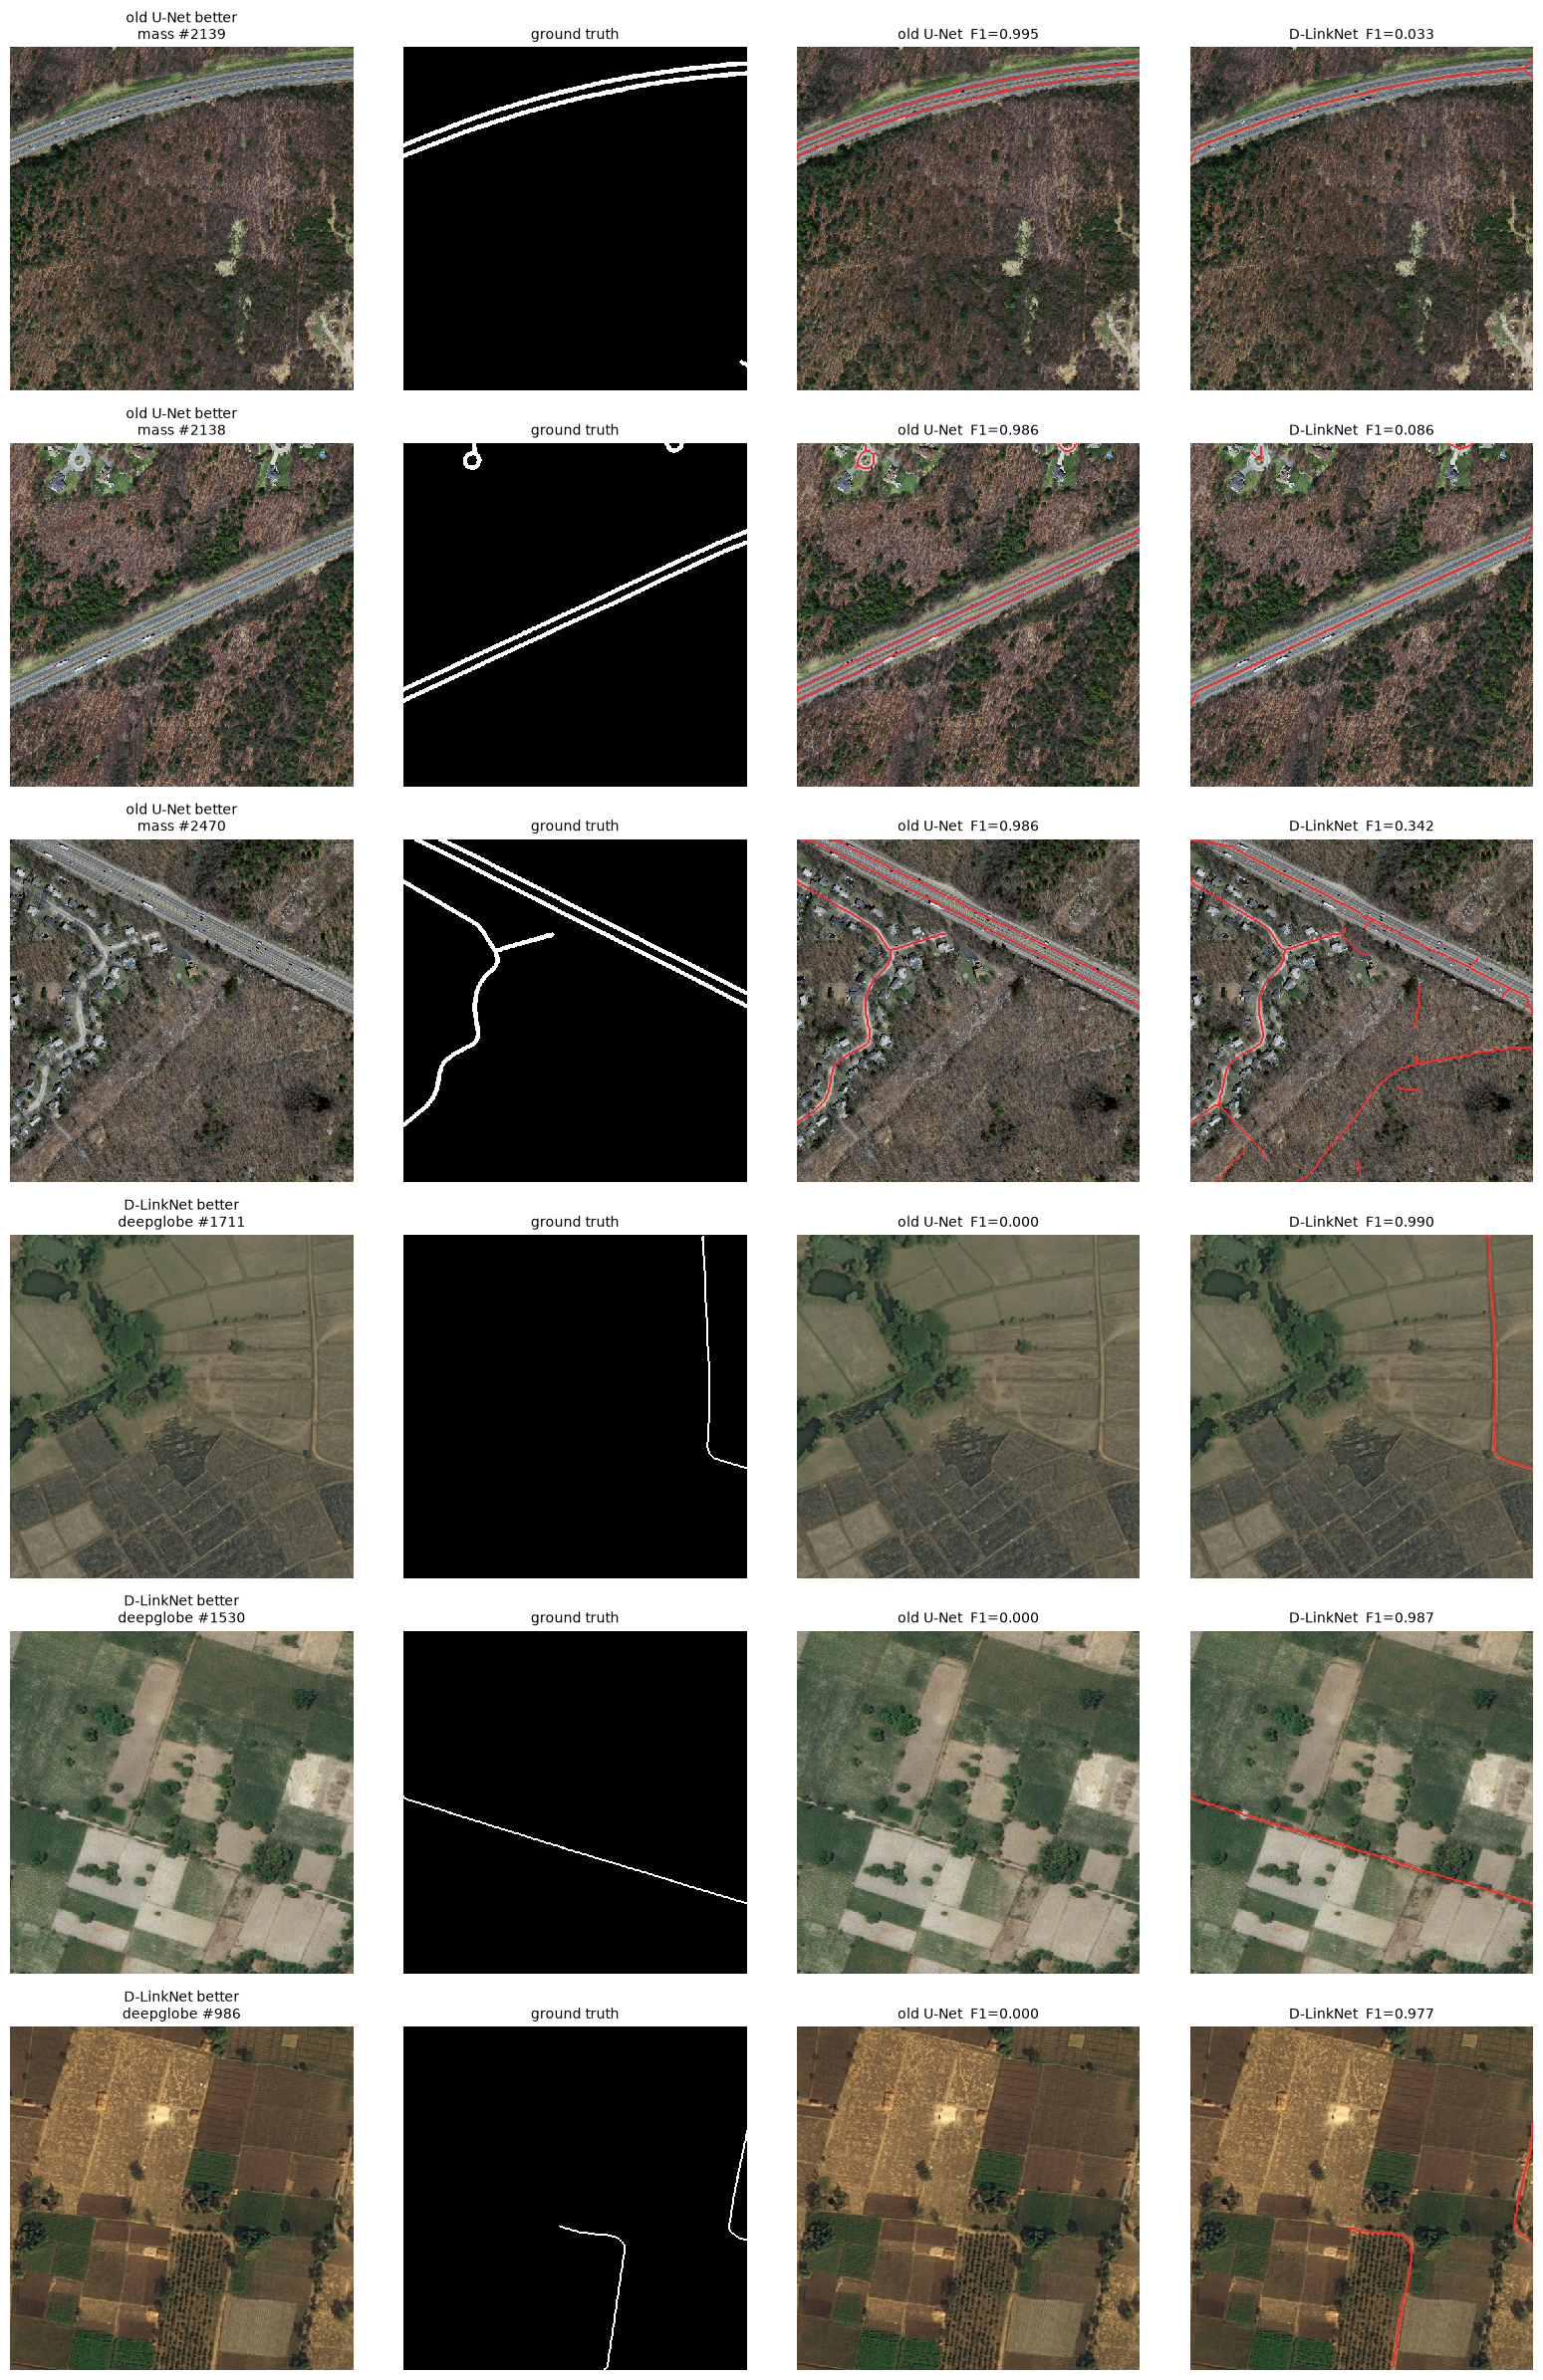

In [6]:
"""Old U-Net (roadseg_merged_dice_best.pt) vs D-LinkNet34 on the test split, per dataset and overall.

Old model: smp.Unet("resnet34"), trained on Massachusetts + DeepGlobe only. No training code
survives, so its input contract was probed: ImageNet normalisation (plain /255 halves recall),
and the Dice loss saturated its sigmoid at 0/1, so thresholds 0.1-0.7 and blur change nothing
-> p > 0.5, no blur. D-LinkNet keeps its own operating point (gaussian 1, p > 0.005).
Everything after the threshold is identical for both: closing, hole/blob cleanup, skeleton,
relaxed 3 px precision / recall / F1 against the GT skeleton -- only the network differs.
"""

import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp
import torch
from scipy import ndimage as ndi
from skimage import morphology
from torch.utils.data import DataLoader
from tqdm import tqdm

from dlinknet import DLinkNet34
from road_dataset import RoadDataset, normalize

ROOT = r"C:\Dev\deeplearning\unified_dataset"
CKPT_DLINK = r"C:\Dev\deeplearning\trained_models\dlinknet34_best.pt"
CKPT_UNET = r"C:\Dev\deeplearning\trained_models\roadseg_merged_dice_best.pt"
OUT = r"C:\Dev\deeplearning\comparison.png"
SPLIT = "test"
BATCH = 16
CLOSE_RADIUS = 2
MIN_AREA = 64
TOL = 3              # px
N_EXAMPLES = 3       # per direction
MIN_GT_PX = 300      # examples only from patches with a real road network to compare

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dlink = DLinkNet34(weights=None)
dlink.load_state_dict(torch.load(CKPT_DLINK, map_location="cpu", weights_only=False)["model"])
unet = smp.Unet("resnet34", encoder_weights=None, classes=1)
unet.load_state_dict(torch.load(CKPT_UNET, map_location="cpu", weights_only=False)["model_state_dict"])
# name -> (network, threshold, gaussian sigma)
models = {"old U-Net": (unet, 0.5, 0.0), "D-LinkNet": (dlink, 0.005, 1.0)}
for net, _, _ in models.values():
    net.to(device, memory_format=torch.channels_last).eval()


def skeleton(prob, threshold, sigma):
    if sigma:
        prob = ndi.gaussian_filter(prob, sigma)
    mask = morphology.closing(prob > threshold, morphology.disk(CLOSE_RADIUS))
    mask = morphology.remove_small_holes(mask, max_size=MIN_AREA)
    mask = morphology.remove_small_objects(mask, max_size=MIN_AREA)
    return morphology.skeletonize(mask)


ds = RoadDataset(ROOT, SPLIT, augment=False)
loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
tol_disk = morphology.disk(TOL)
# per patch, per model: [pred px matched, pred px, gt px matched, gt px]
counts = np.zeros((len(ds), len(models), 4), np.int64)

i = 0
with torch.inference_mode():
    for images, masks, _ in tqdm(loader, desc=f"comparing on {SPLIT}", unit="batch"):
        x = normalize(images, device)
        with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=device.type == "cuda"):
            probs = [torch.sigmoid(net(x).float()).squeeze(1).cpu().numpy() for net, _, _ in models.values()]

        for b, gt in enumerate(masks.squeeze(-1).numpy().astype(bool)):
            sk_gt = morphology.skeletonize(gt)
            gt_zone = ndi.binary_dilation(sk_gt, tol_disk)
            for j, (_, threshold, sigma) in enumerate(models.values()):
                sk = skeleton(probs[j][b], threshold, sigma)
                counts[i, j] = ((sk & gt_zone).sum(), sk.sum(),
                                (sk_gt & ndi.binary_dilation(sk, tol_disk)).sum(), sk_gt.sum())
            i += 1

# --- table ---------------------------------------------------------------------
sids = ds.source_ids.numpy()
groups = [(name, sids == k) for k, name in enumerate(ds.source_names)] + [("ALL", np.ones(len(ds), bool))]
print(f"\n{'dataset':<10} {'patches':>7}" + "".join(f" | {n + ' P':>12} {'R':>6} {'F1':>6}" for n in models))
f1_by_group = {}
for name, sel in groups:
    c = counts[sel].sum(0).astype(float)
    p, r = c[:, 0] / np.maximum(c[:, 1], 1), c[:, 2] / np.maximum(c[:, 3], 1)
    f1_by_group[name] = 2 * p * r / np.maximum(p + r, 1e-9)
    print(f"{name:<10} {sel.sum():>7}" + "".join(f" | {p[j]:>12.4f} {r[j]:>6.4f} {f1_by_group[name][j]:>6.4f}" for j in range(len(models))))
mean_f1 = np.mean([f1_by_group[n] for n in ds.source_names], axis=0)
print(f"{'MEAN':<10} {'':>7}" + "".join(f" | {'':>12} {'':>6} {mean_f1[j]:>6.4f}" for j in range(len(models))))

# --- biggest per-patch F1 gaps --------------------------------------------------
c = counts.astype(float)
p, r = c[..., 0] / np.maximum(c[..., 1], 1), c[..., 2] / np.maximum(c[..., 3], 1)
f1 = 2 * p * r / np.maximum(p + r, 1e-9)                      # (patches, models)
gap = np.where(counts[:, 0, 3] >= MIN_GT_PX, f1[:, 1] - f1[:, 0], np.nan)   # >0: D-LinkNet better
order = np.argsort(gap)[:np.isfinite(gap).sum()]
picks = [("old U-Net better", k) for k in order[:N_EXAMPLES]] + [("D-LinkNet better", k) for k in order[::-1][:N_EXAMPLES]]

fig, axes = plt.subplots(len(picks), 2 + len(models), figsize=(4 * (2 + len(models)), 4 * len(picks)), squeeze=False)
with torch.inference_mode():
    for row, (label, k) in enumerate(picks):
        image, gt, sid = ds[k]
        x = normalize(image.unsqueeze(0), device)
        panels = [(image.numpy(), f"{label}\n{ds.source_names[sid]} #{k}"), (gt.squeeze().numpy(), "ground truth")]
        for j, (name, (net, threshold, sigma)) in enumerate(models.items()):
            with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=device.type == "cuda"):
                prob = torch.sigmoid(net(x).float()).squeeze().cpu().numpy()
            overlay = image.numpy().copy()
            overlay[ndi.binary_dilation(skeleton(prob, threshold, sigma), iterations=1)] = (255, 40, 40)
            panels.append((overlay, f"{name}  F1={f1[k, j]:.3f}"))
        for ax, (im, title) in zip(axes[row], panels):
            ax.imshow(im, cmap="gray" if im.ndim == 2 else None, interpolation="nearest")
            ax.set_title(title, fontsize=10)
            ax.axis("off")

fig.tight_layout()
fig.savefig(OUT, dpi=90)
print(f"[+] saved {OUT}")
